In [29]:
import random_matrix.amplitude_matrix.isotropic_tmatrix as isotropic_tmatrix
from scipy.special import hankel1, spherical_jn, lpmv, h1vp,spherical_yn
import numpy as np
import math
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import pickle

import plotly.graph_objects as go


In [86]:
# Load the results
with open('Ts_full.pkl', 'rb') as f:
    results = pickle.load(f)

Ts_xstretch = np.asarray(results['Ts_xstretch'])
Ts_ystretch = np.asarray(results['Ts_ystretch'])
aspect_ratio = results['stretch_factor']

In [11]:
wavelength1 = 400e-9
k1 = (2 * np.pi) / wavelength1
m = 1.2 # Relative refractive Index
k2 = m * k1
# sampling incident field
n=100
theta_i = 0 * np.ones((100))
phi_i = 0* np.ones((101))
theta_grid_i, phi_grid_i = np.meshgrid(theta_i, phi_i)
# sampling scattered field
theta_s = np.linspace(0, np.pi, n)
phi_s = np.linspace(0, 2 * np.pi, n + 1)
# theta = 0 * np.ones((100))
# phi = 0* np.ones((101))
theta_grid, phi_grid = np.meshgrid(theta_s,phi_s)
radius = 2 / k1
d_theta = np.pi / (n - 1)
d_phi = np.pi / (n)
n_multipole = 2

$$C_{\text{sca}} = \int_{4\pi} \frac{|\mathbf{T}|^2}{k^2 |\mathbf{E}_i|^2} d\Omega$$

In [121]:
input_polarisation = np.linspace(0,2*np.pi,25,endpoint=True) #0 is x-polarised (vertical)
Csca = np.zeros((5,len(input_polarisation)))
for i in range(5):
    T_matrix = Ts_ystretch[2*i,:,:]
    Csca_ar = np.zeros((len(input_polarisation)))
    for idx, input_pol in enumerate(input_polarisation):
        
        A = isotropic_tmatrix.scattering_amplitudes_from_T_v2(theta_grid_i, phi_grid_i, theta_grid, phi_grid, T_matrix, k1, n_multipole)
        Ex = np.cos(input_pol)
        Ey = np.sin(input_pol)
        
        S2 = np.reshape(A[:,0], (n + 1, n))
        S3 = np.reshape(A[:,1], (n + 1, n))
        S4 = np.reshape(A[:,2], (n + 1, n))
        S1 = np.reshape(A[:,3], (n + 1, n))
        Es_theta = S2 * Ex + S3 * Ey
        Es_phi = S4 * Ex + S1 * Ey
        Is = (np.abs(Es_theta) ** 2 + np.abs(Es_phi) ** 2) * np.sin(theta_grid) / k1**2
        inner_integral = np.trapezoid(Is, phi_s, d_phi, axis=0)
        Csca_ar[idx]= np.trapezoid(inner_integral, theta_s, d_theta)#/1.0# (np.pi * aspect_ratio[5*i] * radius ** 2)
    Csca[i] =Csca_ar
 

In [123]:
Csca[0]/(np.pi*radius**2)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0.])

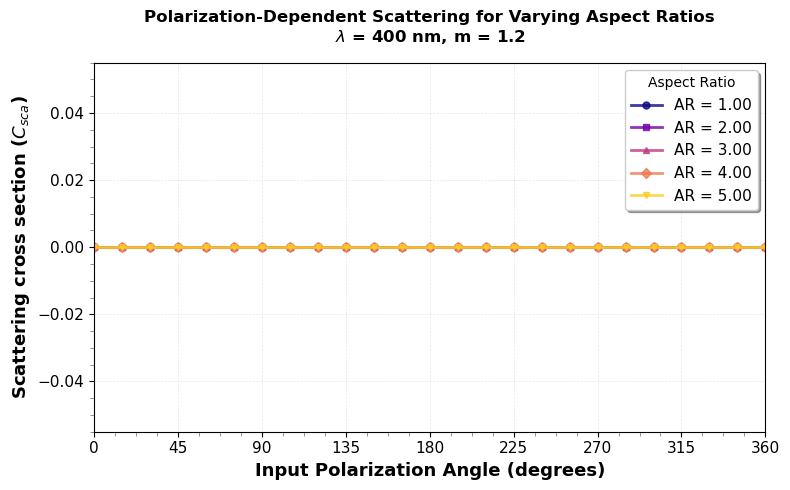

In [117]:
# Create a single, publication-quality plot
fig, ax = plt.subplots(figsize=(8, 5))

x_deg = input_polarisation * 180 / np.pi
colors = plt.cm.plasma(np.linspace(0, 0.9, 5))
markers = ['o', 's', '^', 'D', 'v']

# Plot all aspect ratios on the same axes
for i in range(5):
    ax.plot(x_deg, Csca[i], 
            marker=markers[i], 
            markersize=5, 
            linewidth=2,
            color=colors[i],
            label=f'AR = {aspect_ratio[i*2]:.2f}',
            alpha=0.8)

# Formatting
ax.set_xlabel('Input Polarization Angle (degrees)', fontsize=13, fontweight='bold')
ax.set_ylabel('Scattering cross section ($C_{sca}$)', fontsize=13, fontweight='bold')
ax.set_title('Polarization-Dependent Scattering for Varying Aspect Ratios\n$\\lambda$ = 400 nm, m = 1.2', 
             fontsize=12, fontweight='bold', pad=15)

# Grid and legend
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.legend(loc='best', frameon=True, shadow=True, fontsize=11, title='Aspect Ratio')

# Format axes
ax.set_xlim([0, 360])
ax.set_xticks(np.arange(0, 361, 45))
ax.tick_params(axis='both', which='major', labelsize=11)
# ax.ticklabel_format(style='plain', axis='y', useOffset=False)

# Add minor ticks
ax.minorticks_on()
ax.tick_params(which='minor', length=3, color='gray')

plt.tight_layout()
# plt.savefig('C_sca z stretched ellipse .png', dpi=300)
plt.show()

In [39]:
Ex = 0
Ey=1
T_matrix = Ts_xstretch[4,:,:]
A = isotropic_tmatrix.scattering_amplitudes_from_T_v2(theta_grid_i, phi_grid_i, theta_grid, phi_grid, T_matrix, k1, n_multipole)
S2 = np.reshape(A[:,0], (n + 1, n))
S3 = np.reshape(A[:,1], (n + 1, n))
S4 = np.reshape(A[:,2], (n + 1, n))
S1 = np.reshape(A[:,3], (n + 1, n))
Es_theta = S2 * Ex + S3 * Ey
Es_phi = S4 * Ex + S1 * Ey
Is = (np.abs(Es_theta) ** 2 + np.abs(Es_phi) ** 2)


# ----- 2. Scalar function -----
f = Is
f_norm = (f - f.min()) / (f.max() - f.min())

# ----- 3. Radius deformation -----
alpha = 0.3
r = f_norm

# ----- 4. Cartesian coordinates -----
x = r * np.sin(theta_grid) * np.cos(phi_grid)
y = r * np.sin(theta_grid) * np.sin(phi_grid)
z = r * np.cos(theta_grid)

# ----- 5. Plotly 3D surface -----
fig = go.Figure(data=[go.Surface(
    x=x,
    y=y,
    z=z,
    surfacecolor=f,
    colorscale='Viridis',
    showscale=True,
)])

fig.update_layout(
    title="Deformed Sphere with Scalar Field",
    width=600,
    height=600,
    scene=dict(
        xaxis=dict(title='X', visible=True),
        yaxis=dict(title='Y', visible=True),
        zaxis=dict(title='Z', visible=True),
        aspectmode='data'
    )
)

fig.show()

# # ----- 6. Extract X-Z slice at phi ≈ 0 -----
# phi0_idx = np.argmin(np.abs(phi_grid[:,0] - 0))
# x_slice = x[phi0_idx, :]
# z_slice = z[phi0_idx, :]
# f_slice = f[phi0_idx, :]

# # ----- 7. 2D plot of X-Z slice -----
# plt.figure(figsize=(6,6))
# plt.scatter(x_slice, z_slice, c=f_slice, cmap='viridis')
# plt.xlabel("X")
# plt.ylabel("Z")
# plt.title("X-Z Cross Section (phi = 0)")
# plt.axis('equal')
# plt.colorbar(label='f')
# plt.show()


In [ ]:
Ex = 0
Ey= 1
T_matrix = Ts_ystretch[8,:,:]
A = isotropic_tmatrix.scattering_amplitudes_from_T_v2(theta_grid_i, phi_grid_i, theta_grid, phi_grid, T_matrix, k1, n_multipole)
S2 = np.reshape(A[:,0], (n + 1, n))
S3 = np.reshape(A[:,1], (n + 1, n))
S4 = np.reshape(A[:,2], (n + 1, n))
S1 = np.reshape(A[:,3], (n + 1, n))
Es_theta = S2 * Ex + S3 * Ey
Es_phi = S4 * Ex + S1 * Ey
Is = (np.abs(Es_theta) ** 2 + np.abs(Es_phi) ** 2)


# ----- 2. Scalar function -----
f = Is
f_norm = (f - f.min()) / (f.max() - f.min())

# ----- 3. Radius deformation -----
alpha = 0.3
r = f_norm

# ----- 4. Cartesian coordinates -----
x = r * np.sin(theta_grid) * np.cos(phi_grid)
y = r * np.sin(theta_grid) * np.sin(phi_grid)
z = r * np.cos(theta_grid)

# ----- 5. Plotly 3D surface -----
fig = go.Figure(data=[go.Surface(
    x=x,
    y=y,
    z=z,
    surfacecolor=f,
    colorscale='Viridis',
    showscale=True,
)])

fig.update_layout(
    title="Deformed Sphere with Scalar Field",
    width=600,
    height=600,
    scene=dict(
        xaxis=dict(title='X', visible=True),
        yaxis=dict(title='Y', visible=True),
        zaxis=dict(title='Z', visible=True),
        aspectmode='data'
    )
)

fig.show()

# # ----- 6. Extract X-Z slice at phi ≈ 0 -----
# phi0_idx = np.argmin(np.abs(phi_grid[:,0] - 0))
# x_slice = x[phi0_idx, :]
# z_slice = z[phi0_idx, :]
# f_slice = f[phi0_idx, :]

# # ----- 7. 2D plot of X-Z slice -----
# plt.figure(figsize=(6,6))
# plt.scatter(x_slice, z_slice, c=f_slice, cmap='viridis')
# plt.xlabel("X")
# plt.ylabel("Z")
# plt.title("X-Z Cross Section (phi = 0)")
# plt.axis('equal')
# plt.colorbar(label='f')
# plt.show()


In [2]:
# Creates the Convex hull for a sphere of size 600nm
wavelength1 = 400e-9
k1 = (2 * np.pi) / wavelength1
m = 1.2 # Relative refractive Index
k2 = m * k1
n_max = 2



In [ ]:
def ellipse_hull(lx,ly,lz):
    """
    Generate a rotated ellipsoid, compute its convex hull, 
    and plot both the 3D shape and its 2D XY projection.
    
    Parameters
    ----------
    a, b, c : float
        Semi-axes of the ellipsoid along x, y, z.
    R : np.ndarray
        3x3 rotation matrix defining the ellipsoid orientation.
    n_points : int
        Number of samples .
    """
    n_samples= 100
    # ---- 1. Generate ellipsoid surface points
    u = np.linspace(0, 2*np.pi, n_samples)
    v = np.linspace(0, np.pi, n_samples)
    u, v = np.meshgrid(u, v)

    x = lx * np.cos(u) * np.sin(v)
    y = ly * np.sin(u) * np.sin(v)
    z = lz * np.cos(v)

    # Stack and rotate
    points = np.vstack((x.flatten(), y.flatten(), z.flatten()))
    rotated_points =  points  # shape (3, N)

    # ---- 2. 3D Convex hull
    hull_3d = ConvexHull(rotated_points.T)

    return hull_3d

In [ ]:
# sampling incident field
n=100
theta_i = 0 * np.ones((100))
phi_i = 0* np.ones((101))
theta_grid_i, phi_grid_i = np.meshgrid(theta_i, phi_i)
# sampling scattered field
theta = np.linspace(0, np.pi, n)
phi = np.linspace(0, 2 * np.pi, n + 1)
# theta = 0 * np.ones((100))
# phi = 0* np.ones((101))
theta_grid, phi_grid = np.meshgrid(theta, phi)
radius = 2 / k1
d_theta = np.pi / (n - 1)
d_phi = np.pi / (n)
r = 2/k1
size = np.arange(1,2,0.1)
result_x = np.zeros(len(size))
result_y = np.zeros(len(size))
for idx, factor in enumerate(size):
    # Semi-axes lengths
    lx,ly,lz= r,factor*r,r

    # Use the same plotting function defined before
    hull_ellipse = ellipse_hull(lx, ly, lz)
    T_ellipse = isotropic_tmatrix.get_T(hull_ellipse, k1, k2, n_max)
    A = isotropic_tmatrix.scattering_amplitudes_from_T_v2(theta_grid_i, phi_grid_i, theta_grid, phi_grid, T_ellipse, k1, n_max)

    S2 = np.reshape(A[:,0], (n + 1, n))
    S3 = np.reshape(A[:,1], (n + 1, n))
    S4 = np.reshape(A[:,2], (n + 1, n))
    S1 = np.reshape(A[:,3], (n + 1, n))
    # T = (np.abs(S2-1j*S3) ** 2 + np.abs(S4-1j*S1) ** 2) * np.sin(theta_grid) / k1**2
    E_x= (np.abs(S4) ** 2 + np.abs(S2) ** 2) * np.sin(theta_grid) / k1**2
    inner_integral = np.trapezoid(E_x, phi, d_phi, axis=0)
    result_x[idx]= np.trapezoid(inner_integral, theta, d_theta) / (np.pi * radius ** 2)
    E_y= (np.abs(S3) ** 2 + np.abs(S1) ** 2) * np.sin(theta_grid) / k1**2
    inner_integral = np.trapezoid(E_y, phi, d_phi, axis=0)
    result_y[idx] = np.trapezoid(inner_integral, theta, d_theta) / (np.pi * radius ** 2)

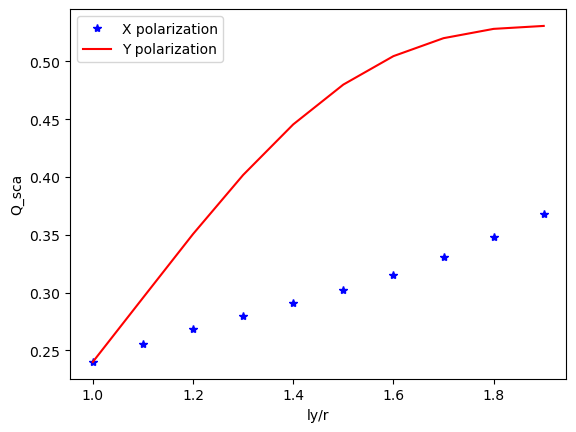

In [15]:
plt.plot(size,result_x,'b*',label='X polarization')
plt.plot(size,result_y,'r-',label='Y polarization')
plt.legend()
plt.xlabel('ly/r')
plt.ylabel('Q_sca')
plt.savefig('y_stretch.png',dpi=300)

In [3]:
def ellipse_hull_rotated(lx,ly,lz, R):
    """
    Generate a rotated ellipsoid, compute its convex hull, 
    and plot both the 3D shape and its 2D XY projection.
    
    Parameters
    ----------
    a, b, c : float
        Semi-axes of the ellipsoid along x, y, z.
    R : np.ndarray
        3x3 rotation matrix defining the ellipsoid orientation.
    n_points : int
        Number of samples .
    """
    n_samples= 100
    # ---- 1. Generate ellipsoid surface points
    u = np.linspace(0, 2*np.pi, n_samples)
    v = np.linspace(0, np.pi, n_samples)
    u, v = np.meshgrid(u, v)

    x = lx * np.cos(u) * np.sin(v)
    y = ly * np.sin(u) * np.sin(v)
    z = lz * np.cos(v)

    # Stack and rotate
    points = np.vstack((x.flatten(), y.flatten(), z.flatten()))
    rotated_points =  R@points  # shape (3, N)

    # ---- 2. 3D Convex hull
    hull_3d = ConvexHull(rotated_points.T)

    return hull_3d

In [5]:
# sampling incident field
n=100
theta_i = 0 * np.ones((100))
phi_i = 0* np.ones((101))
theta_grid_i, phi_grid_i = np.meshgrid(theta_i, phi_i)
# sampling scattered field
theta = np.linspace(0, np.pi, n)
phi = np.linspace(0, 2 * np.pi, n + 1)
# theta = 0 * np.ones((100))
# phi = 0* np.ones((101))
theta_grid, phi_grid = np.meshgrid(theta, phi)
radius = 2 / k1
d_theta = np.pi / (n - 1)
d_phi = np.pi / (n)
r = 2/k1
angles = np.arange(0, 2*np.pi, np.pi/4)
result_x = np.zeros(len(angles))
result_y = np.zeros(len(angles))
for idx, angle in enumerate(angles):
    # Semi-axes lengths
    lx,ly,lz= r,r,1.5*r
    # rotation about y by `angle`
    c = np.cos(angle)
    s = np.sin(angle)
    R = np.array([[ c, 0.0,  s],
                  [0.0, 1.0, 0.0],
                  [-s, 0.0,  c]])
    # Use the same plotting function defined before
    hull_ellipse = ellipse_hull_rotated(lx, ly, lz, R)
    T_ellipse = isotropic_tmatrix.get_T(hull_ellipse, k1, k2, n_max)
    A = isotropic_tmatrix.scattering_amplitudes_from_T_v2(theta_grid_i, phi_grid_i, theta_grid, phi_grid, T_ellipse, k1, n_max)

    S2 = np.reshape(A[:,0], (n + 1, n))
    S3 = np.reshape(A[:,1], (n + 1, n))
    S4 = np.reshape(A[:,2], (n + 1, n))
    S1 = np.reshape(A[:,3], (n + 1, n))
    # T = (np.abs(S2-1j*S3) ** 2 + np.abs(S4-1j*S1) ** 2) * np.sin(theta_grid) / k1**2
    E_x= (np.abs(S4) ** 2 + np.abs(S2) ** 2) * np.sin(theta_grid) / k1**2
    inner_integral = np.trapezoid(E_x, phi, d_phi, axis=0)
    result_x[idx]= np.trapezoid(inner_integral, theta, d_theta) / (np.pi * radius ** 2)
    E_y= (np.abs(S3) ** 2 + np.abs(S1) ** 2) * np.sin(theta_grid) / k1**2
    inner_integral = np.trapezoid(E_y, phi, d_phi, axis=0)
    result_y[idx] = np.trapezoid(inner_integral, theta, d_theta) / (np.pi * radius ** 2)

Number of modes: 8 


  0%|          | 0/8 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:25<00:00,  3.21s/it]


Number of modes: 8 


100%|██████████| 8/8 [00:25<00:00,  3.21s/it]


...

100%|██████████| 8/8 [00:25<00:00,  3.22s/it]


Number of modes: 8 


100%|██████████| 8/8 [00:25<00:00,  3.21s/it]


Number of modes: 8 


100%|██████████| 8/8 [00:25<00:00,  3.22s/it]


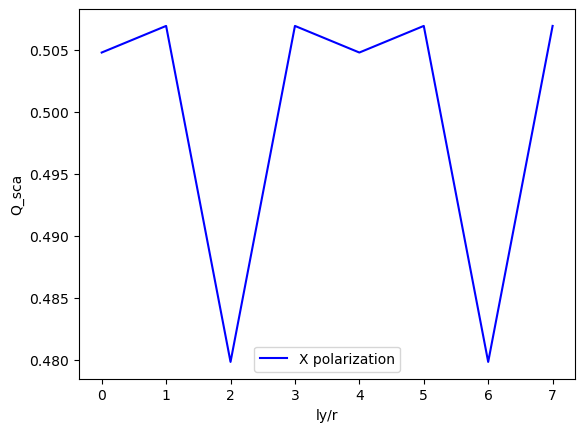

In [12]:
plt.plot(result_x,'b-',label='X polarization')
# plt.plot(angles,result_y,'r-',label='Y polarization')
plt.legend()
plt.xlabel('ly/r')
plt.ylabel('Q_sca')
plt.savefig('rotated.png',dpi=300)

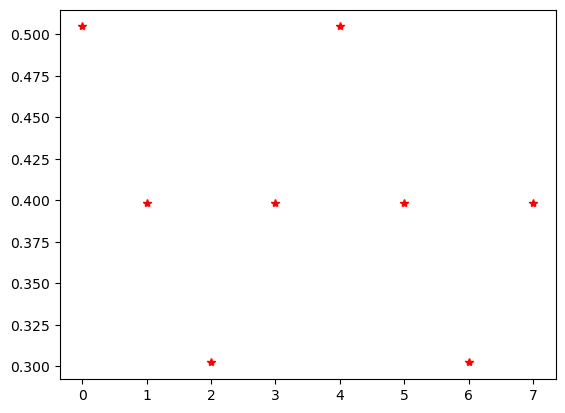

In [15]:
plt.plot(result_y,'r*',label='Y polarization')

In [14]:
result_y

array([0.50476679, 0.39873559, 0.30241418, 0.39873558, 0.50476679,
       0.39873559, 0.30241418, 0.39873558])

In [ ]:
    A = isotropic_tmatrix.scattering_amplitudes_from_T_v2(theta_grid_i, phi_grid_i, theta_grid, phi_grid, T_ellipse, k1, n_max)

    S2 = np.reshape(A[:,0], (n + 1, n))
    S3 = np.reshape(A[:,1], (n + 1, n))
    S4 = np.reshape(A[:,2], (n + 1, n))
    S1 = np.reshape(A[:,3], (n + 1, n))
    # T = (np.abs(S2-1j*S3) ** 2 + np.abs(S4-1j*S1) ** 2) * np.sin(theta_grid) / k1**2
    T = (np.abs(S3) ** 2 + np.abs(S1) ** 2) * np.sin(theta_grid) / k1**2
    inner_integral = np.trapezoid(T, phi, d_phi, axis=0)
    result_y = np.trapezoid(inner_integral, theta, d_theta) / (np.pi * radius ** 2)

In [ ]:
r = 2/k1


a, b, c = r,r,1.5*r

# Use the same plotting function defined before
hull_ellipse = plot_ellipsoid_with_xy_projection(a, b, c)
T = isotropic_tmatrix.get_T(hull_ellipse, k1, k2, n_max)
# sampling incident field
n=100
theta_i = 0 * np.ones((100))
phi_i = 0* np.ones((101))
theta_grid_i, phi_grid_i = np.meshgrid(theta_i, phi_i)
# sampling scattered field
theta = np.linspace(0, np.pi, n)
phi = np.linspace(0, 2 * np.pi, n + 1)
# theta = 0 * np.ones((100))
# phi = 0* np.ones((101))
theta_grid, phi_grid = np.meshgrid(theta, phi)
A = isotropic_tmatrix.scattering_amplitudes_from_T_v2(theta_grid_i, phi_grid_i, theta_grid, phi_grid, T_ellipse, k1, n_max)
radius = 2 / k1
d_theta = np.pi / (n - 1)
d_phi = np.pi / (n)
S2 = np.reshape(A[:,0], (n + 1, n))
S3 = np.reshape(A[:,1], (n + 1, n))
S4 = np.reshape(A[:,2], (n + 1, n))
S1 = np.reshape(A[:,3], (n + 1, n))
# T = (np.abs(S2-1j*S3) ** 2 + np.abs(S4-1j*S1) ** 2) * np.sin(theta_grid) / k1**2
T = (np.abs(S3) ** 2 + np.abs(S1) ** 2) * np.sin(theta_grid) / k1**2
inner_integral = np.trapezoid(T, phi, d_phi, axis=0)
result_y = np.trapezoid(inner_integral, theta, d_theta) / (np.pi * radius ** 2)



In [ ]:
hull_uniform = isotropic_tmatrix.create_hull_uniform(2, k1) 

T_uniform= isotropic_tmatrix.get_T(hull_uniform,  k1, k2, n_max)

In [23]:
# sampling incident field
n=100
theta_i = 0 * np.ones((100))
phi_i = 0* np.ones((101))
theta_grid_i, phi_grid_i = np.meshgrid(theta_i, phi_i)
# sampling scattered field
theta = np.linspace(0, np.pi, n)
phi = np.linspace(0, 2 * np.pi, n + 1)
# theta = 0 * np.ones((100))
# phi = 0* np.ones((101))
theta_grid, phi_grid = np.meshgrid(theta, phi)
A = isotropic_tmatrix.scattering_amplitudes_from_T_v2(theta_grid_i, phi_grid_i, theta_grid, phi_grid, T_uniform, k1, n_max)
radius = 2 / k1
d_theta = np.pi / (n - 1)
d_phi = np.pi / (n)
S2 = np.reshape(A[:,0], (n + 1, n))
S3 = np.reshape(A[:,1], (n + 1, n))
S4 = np.reshape(A[:,2], (n + 1, n))
S1 = np.reshape(A[:,3], (n + 1, n))
# T = (np.abs(S2-1j*S3) ** 2 + np.abs(S4-1j*S1) ** 2) * np.sin(theta_grid) / k1**2
T = (np.abs(S3) ** 2 + np.abs(S1) ** 2) * np.sin(theta_grid) / k1**2
inner_integral = np.trapezoid(T, phi, d_phi, axis=0)
result = np.trapezoid(inner_integral, theta, d_theta) / (np.pi * radius ** 2)

In [22]:
result

np.float64(0.23904309257655088)

In [24]:
result

np.float64(0.2390430925765651)

In [2]:
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_ellipsoid_with_xy_projection(a, b, c, R, n_points=100):
    """
    Generate a rotated ellipsoid, compute its convex hull, 
    and plot both the 3D shape and its 2D XY projection.
    
    Parameters
    ----------
    a, b, c : float
        Semi-axes of the ellipsoid along x, y, z.
    R : np.ndarray
        3x3 rotation matrix defining the ellipsoid orientation.
    n_points : int
        Number of samples .
    """

    # ---- 1. Generate ellipsoid surface points
    u = np.linspace(0, 2*np.pi, n_points)
    v = np.linspace(0, np.pi, n_points)
    u, v = np.meshgrid(u, v)

    x = a * np.cos(u) * np.sin(v)
    y = b * np.sin(u) * np.sin(v)
    z = c * np.cos(v)

    # Stack and rotate
    points = np.vstack((x.flatten(), y.flatten(), z.flatten()))
    rotated_points = R @ points  # shape (3, N)

    # ---- 2. 3D Convex hull
    hull_3d = ConvexHull(rotated_points.T)

    # ---- 3. 2D projection onto XY plane
    xy_points = rotated_points[:2, :].T  # drop z
    hull_2d = ConvexHull(xy_points)

    # ---- 4. Plot 3D ellipsoid and its convex hull
    fig = plt.figure(figsize=(12, 6))

    # --- (a) 3D plot
    ax3d = fig.add_subplot(121, projection='3d')
    for simplex in hull_3d.simplices:
        tri = rotated_points[:, simplex].T
        ax3d.add_collection3d(Poly3DCollection([tri], alpha=0.3, edgecolor='k', facecolor='cyan'))

    ax3d.set_xlabel('X')
    ax3d.set_ylabel('Y')
    ax3d.set_zlabel('Z')
    ax3d.set_box_aspect([1,1,1])
    ax3d.set_title("3D Ellipsoid Convex Hull")

    # --- (b) 2D projection plot
    ax2d = fig.add_subplot(122)
    ax2d.plot(xy_points[:,0], xy_points[:,1], 'r.', alpha=0.3, label='Projected Points')
    for simplex in hull_2d.simplices:
        ax2d.plot(xy_points[simplex,0], xy_points[simplex,1], 'k-')

    ax2d.set_aspect('equal')
    ax2d.set_xlabel('X')
    ax2d.set_ylabel('Y')
    ax2d.set_title("2D Projection on XY Plane")
    ax2d.legend()

    plt.tight_layout()
    plt.show()

    return hull_3d, hull_2d



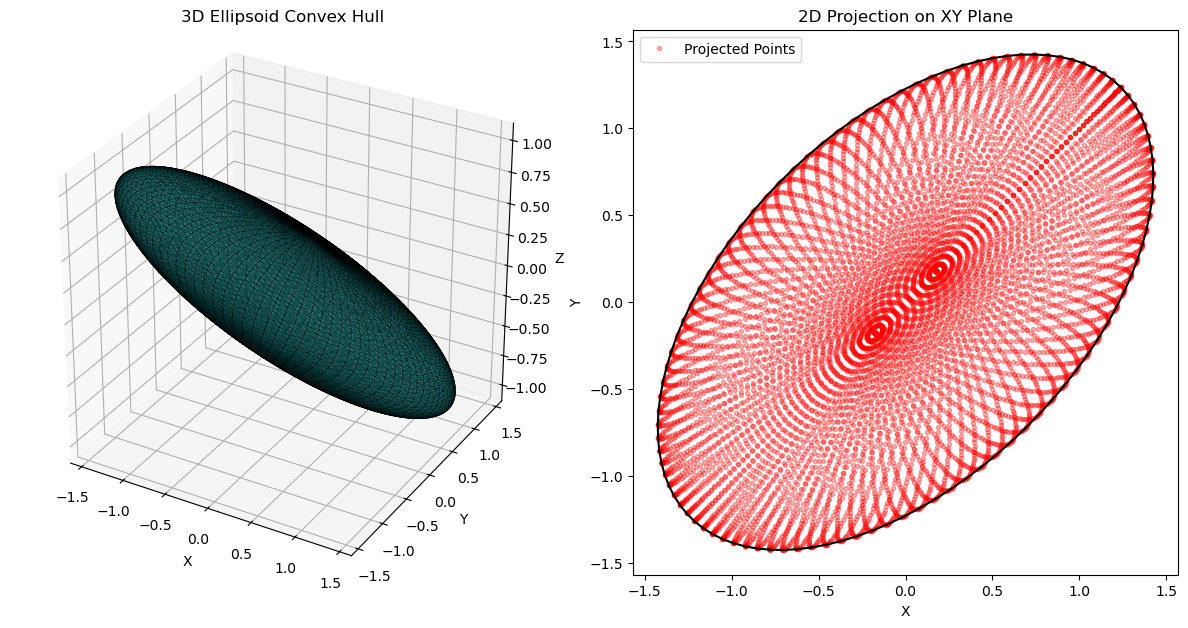

In [5]:

# Semi-axes
a, b, c = 2.0, 1.0, 0.5

# Example rotation (45° about z, 30° about y)
Rz = np.array([[np.cos(np.pi/4), -np.sin(np.pi/4), 0],
               [np.sin(np.pi/4),  np.cos(np.pi/4), 0],
               [0, 0, 1]])
Ry = np.array([[np.cos(np.pi/6), 0, np.sin(np.pi/6)],
               [0, 1, 0],
               [-np.sin(np.pi/6), 0, np.cos(np.pi/6)]])
R = Rz @ Ry

# Plot both 3D ellipsoid and 2D projection
hull_3d, hull_2d = plot_ellipsoid_with_xy_projection(a, b, c, R)


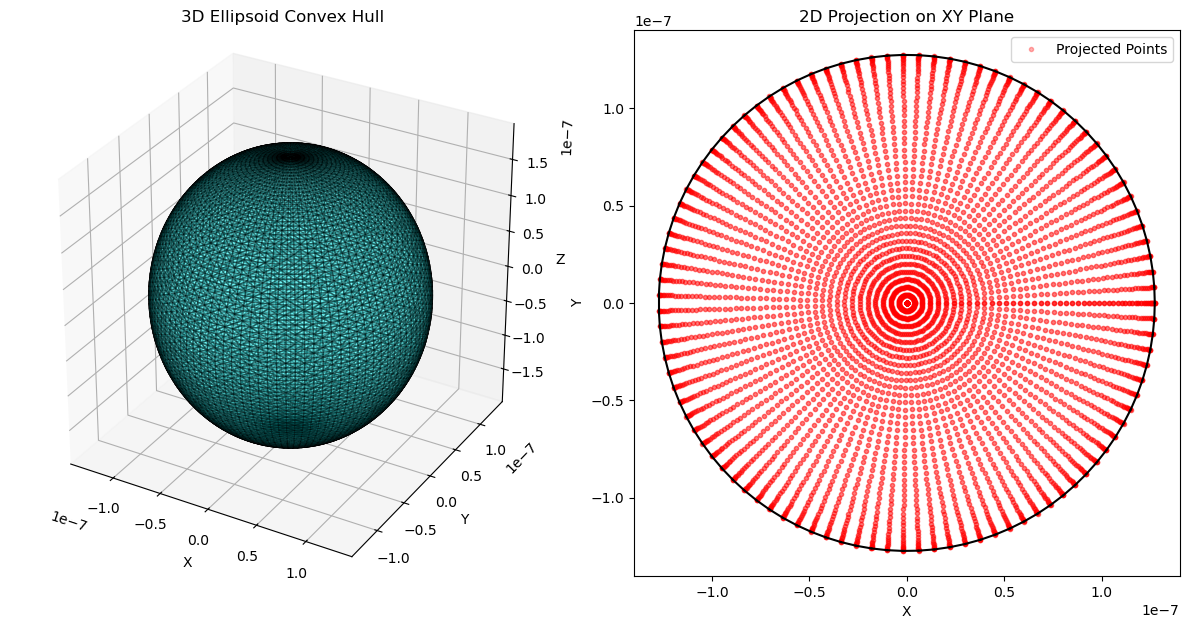

In [5]:

r = 2/k1
# Semi-axes lengths
a, b, c = r,r,1.5*r

# No rotation — identity matrix
R = np.eye(3)

# Use the same plotting function defined before
hull_3d, hull_2d = plot_ellipsoid_with_xy_projection(a, b, c, R)


In [6]:
T_ellipse = isotropic_tmatrix.get_T(hull_3d,  k1, k2, 2)

Number of modes: 8 


100%|██████████| 8/8 [00:25<00:00,  3.22s/it]


In [10]:
# sampling incident field
n=100
theta_i = 0 * np.ones((100))
phi_i = 0* np.ones((101))
theta_grid_i, phi_grid_i = np.meshgrid(theta_i, phi_i)
# sampling scattered field
theta = np.linspace(0, np.pi, n)
phi = np.linspace(0, 2 * np.pi, n + 1)
# theta = 0 * np.ones((100))
# phi = 0* np.ones((101))
theta_grid, phi_grid = np.meshgrid(theta, phi)
A = isotropic_tmatrix.scattering_amplitudes_from_T_v2(theta_grid_i, phi_grid_i, theta_grid, phi_grid, T_ellipse, k1, n_max)
radius = 2 / k1
d_theta = np.pi / (n - 1)
d_phi = np.pi / (n)
S2 = np.reshape(A[:,0], (n + 1, n))
S3 = np.reshape(A[:,1], (n + 1, n))
S4 = np.reshape(A[:,2], (n + 1, n))
S1 = np.reshape(A[:,3], (n + 1, n))
# T = (np.abs(S2-1j*S3) ** 2 + np.abs(S4-1j*S1) ** 2) * np.sin(theta_grid) / k1**2
T = (np.abs(S3) ** 2 + np.abs(S1) ** 2) * np.sin(theta_grid) / k1**2
inner_integral = np.trapezoid(T, phi, d_phi, axis=0)
result_y = np.trapezoid(inner_integral, theta, d_theta) / (np.pi * radius ** 2)


In [8]:
result_x

np.float64(0.504766791851739)

In [11]:
result_y

np.float64(0.5047667918517394)

In [5]:
hull_inv_transform = isotropic_tmatrix.create_hull_inv_transform() # Creates the Convex hull for a sphere of size 600nm

wavelength1 = 532e-9
k1 = (2 * np.pi) / wavelength1
m = 1.5 # Relative refractive Index
k2 = m * k1
n_max = 2

T_inv_transform= isotropic_tmatrix.get_T(hull_inv_transform,  k1, k2, n_max)

Number of simplices: 4802
Number of modes: 8 


100%|██████████| 8/8 [00:10<00:00,  1.30s/it]


In [9]:
true_area = 4*np.pi*(600e-9)**2
print("Error in area for uniform sampled sphere",np.abs(hull_uniform.area-true_area))
print("Error in area for inverse transformed sampled sphere",np.abs(hull_inv_transform.area-true_area))

Error in area for uniform sampled sphere 8.42380993504889e-15
Error in area for inverse transformed sampled sphere 9.77041606994078e-15


2. Functions that calculate required constants.

In [4]:

def alph_mn_mpnp(m,n,mpr,npr):
    
    return (-1)**(m+mpr)*(1j)**(npr-n-1)*np.sqrt(((2*n+1)*(2*npr+1)/(n*(n+1)*npr*(npr+1))))

def h_n(n, kr):
    return spherical_jn(n, kr) + 1j * spherical_yn(n, kr)


def dh_n(n, x):
    """Computes the derivative of the spherical Hankel function of the first kind."""
    hn = h_n(n, x)
    hn1 = h_n(n + 1, x)
    return (n / x) * hn - hn1

def b_n(n, m, x):
    psi_n_x = x*spherical_jn(n, x)
    psi_n_mx = m*x*spherical_jn(n, m * x)
    psi_n_x_derivative = x*spherical_jn(n, x, derivative=True)+spherical_jn(n,x)
    psi_n_mx_derivative = (m*x*spherical_jn(n, m * x, derivative=True)+spherical_jn(n,m*x))
    xi_n_x = x*h_n(n, x)
    xi_n_x_derivative = x*dh_n(n, x)+h_n(n,x)
    
    num = m * psi_n_x * psi_n_mx_derivative - psi_n_mx * psi_n_x_derivative
    den = m * xi_n_x * psi_n_mx_derivative - psi_n_mx * xi_n_x_derivative
    
    return num / den




In [5]:
wavelength1 = 532e-9
k1 = (2 * np.pi) / wavelength1
r =600e-9
x = k1*r
rri = 1.5
n=1

print("n=1")
bn = b_n(n,1.5,x)
print("Analytical Mie theory b_n value:",b_n(n,1.5,x))
computed_b_n = -1j*(n*(n+1)/(2*n+1))*alph_mn_mpnp(0,1,0,1)*T_uniform[1][1]
print("Computed b_n vlaues from T matrix",computed_b_n)
print("Error:",np.abs(computed_b_n-bn))


n=1
Analytical Mie theory b_n value: (0.18554725921886245-0.38874088261363854j)
Computed b_n vlaues from T matrix (0.18519673563717184-0.38845708224526854j)
Error: 0.00045100934625366495


In [6]:
wavelength1 = 532e-9
k1 = (2 * np.pi) / wavelength1
r =600e-9
x = k1*r
rri = 1.5
n=1
print("n=1")
bn = b_n(n,1.5,x)
print("Analytical Mie theory b_n value:",b_n(n,1.5,x))
computed_b_n = -1j*(n*(n+1)/(2*n+1))*alph_mn_mpnp(0,1,0,1)*T_inv_transform[1][1]
print("Computed b_n vlaues from T matrix",computed_b_n)
print("Error:",np.abs(computed_b_n-bn))

n=1
Analytical Mie theory b_n value: (0.18554725921886245-0.38874088261363854j)


NameError: name 'T_inv_transform' is not defined

In [ ]:
# @staticmethod
def integration_check(n1, m1, n2, m2):
    wavelength1 = 532e-9
    k1 = (2 * np.pi) / wavelength1
    wavelength2 = 266e-9
    k2 = (2 * np.pi) / wavelength2
    row = 50
    col = 51
    num_linear = row * col
    theta = np.linspace(0, np.pi, col)
    phi = np.linspace(0, 2 * np.pi, row)
    theta_grid, phi_grid = np.meshgrid(theta, phi)
    r = 10e-9

    def integrand1(theta, phi):

        RgM = RgM_mn(0, 1, k2 * r, theta, phi)
        N = N_mn(0, 1, k1 * r, theta, phi)
        result = (RgM[0] * N[2] - RgM[1] * N[1]) * r**2 * np.sin(theta)

        return result

    def integrand2(theta, phi):
        B1 = B_mn(m1, n1, theta, phi)
        B2 = B_mn(m2, n2, theta, phi)
        return (B1[0] * np.conj(B2[0]) + B1[1] * np.conj(B2[1])) * np.sin(theta)

    def integrand3(theta, phi):
        C1 = C_mn(m1, n1, theta, phi)
        C2 = C_mn(m2, n2, theta, phi)
        return (C1[0] * np.conj(C2[0]) + C1[1] * np.conj(C2[1])) * np.sin(theta)

    def integrand4(theta, phi):
        M1 = M_mn(1, 1, k1, theta, phi)
        M2 = M_mn(1, 1, k1, theta, phi)
        return (M1[0] * np.conj(M2[0]) + M1[1] * np.conj(M2[1])) * np.sin(theta)

    def integrand5(theta, phi):
        P1 = P_mn(m1, n1, theta, phi)
        P2 = P_mn(m2, n2, theta, phi)
        return P1 * np.conj(P2) * np.sin(theta)

        # Compute the integral over [-1, 1]
        # n = 1
        # m = 1

        # gamma_mn = np.sqrt(
        ((2 * n + 1) * factorial(n - m)) / (4 * np.pi * n * (n + 1) * factorial(n + m))

    # )
    result, _ = dblquad(integrand3, 0, 2 * np.pi, 0, np.pi)
    # r = result / (h_n(n, k) * np.conj(h_n(n, k)))
    return result


"""
hull, points = create_hull()
wavelength1 = 532e-9
k1 = (2 * np.pi) / wavelength1
wavelength2 = 266e-9
k2 = 1.5 * k1
n_max = 2
modes = sum(2 * n + 1 for n in range(1, n_max + 1))
print(f"Total number of modes is {modes}")
T = get_T(hull, points, k1, k2, n_max)
plt.matshow(np.abs(T), cmap="viridis")
plt.title("T Matrix")
plt.colorbar()
plt.show()
"""


n=1  
Sampling used : 100 uniform phi points and 101 uniform theta point  
Analytical Mie theory b_n value: (-0.05043054394533954-0.19384157896230952j)  
Computed b_n vlaues from T matrix (-0.050229944914698905-0.1949243621541355j)

Sampling used : 50 uniform phi points and 51 uniform theta point  
Analytical Mie theory b_n value: (-0.05043054394533954-0.19384157896230952j)  
Computed b_n vlaues from T matrix (-0.05021801181055005-0.1947708794468376j)